In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/customer_churn_business_dataset.csv')

display(df.head())

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


### 7. Préparation et Transformation des Données (Preprocessing)

L'exécution de notre pipeline de prétraitement a généré les résultats suivants, confirmant la bonne préparation de nos matrices d'apprentissage :

#### Feature Engineering

*   **Résultat :** Variable 'engagement\_score' créée avec succès. Moyenne : 0.430
    
*   **Analyse :** La création du score synthétique s'est déroulée correctement. La moyenne de 0.43 (sur une échelle normalisée de 0 à 1) indique un engagement global moyen/faible de la base utilisateur. Cette nouvelle variable agrégée offre aux algorithmes un signal métier "prémâché" très puissant.
    

#### Stratified Train/Test Split

*   **Résultat (Train - 8000 lignes) :** 0: 89.7% | 1: 10.2%
    
*   **Résultat (Test - 2000 lignes) :** 0: 89.8% | 1: 10.2%
    
*   **Analyse :** Le fractionnement stratifié (stratify=y) a parfaitement fonctionné. Il garantit que nos deux ensembles de données reflètent exactement la réalité du déséquilibre d'origine (environ 10% de churners). C'est crucial : si nous avions eu 15% de churners dans le Train et 5% dans le Test par un hasard statistique (Split aléatoire classique), l'évaluation finale du modèle aurait été totalement faussée.
    

#### Pipeline de Transformation Automatisé

*   **Résultat :** Variables numériques à standardiser (20) et Variables catégorielles à encoder (11)
    
*   **Résultat final :** Dimensions après transformation : 48 features.
    
*   **Analyse :** Le ColumnTransformer a correctement détecté et séparé les flux de traitement. Les 11 variables textuelles ont été encodées en variables binaires via le OneHotEncoder(drop='first'), évitant ainsi le piège de la colinéarité parfaite. Cet éclatement des catégories explique l'augmentation du nombre total de colonnes (passant d'une trentaine à 48 _features_ mathématiques). Toutes les variables numériques ont été centrées-réduites via le StandardScaler, une étape indispensable pour la convergence rapide de notre future Régression Logistique et de notre Réseau de Neurones.
    

#### Rééchantillonnage Synthétique (SMOTE)

*   **Résultat avant SMOTE (Train) :** 8 000 lignes (très déséquilibrées).
    
*   **Résultat après SMOTE (Train) :** 14 366 lignes (7 183 de classe 0 et 7 183 de classe 1).
    
*   **Analyse :** L'algorithme SMOTE a détecté la classe minoritaire (les 10% de churners du set d'entraînement) et a généré mathématiquement de nouveaux profils synthétiques "ressemblants". Le jeu d'entraînement est désormais parfaitement équilibré (50/50). Les algorithmes de Machine Learning que nous allons entraîner ne seront plus "aveuglés" par la classe majoritaire et apprendront à détecter efficacement les signaux d'attrition.
    
*   **Point de vigilance validé :** Cette opération de "triche bienveillante" n'a été appliquée que sur le jeu d'entraînement (X\_train). Le jeu de test (X\_test), qui servira à juger le modèle, reste pur et conserve son déséquilibre naturel (10% de churners), simulant ainsi une véritable mise en production.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

# 0. Chargement et exclusion des identifiants non prédictifs
# (Supposons que df contient le dataset chargé)
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

# ---------------------------------------------------------
# 1. FEATURE ENGINEERING : CRÉATION DU SCORE D'ENGAGEMENT
# ---------------------------------------------------------
print("--- Étape 1 : Feature Engineering ---")

# Normalisation MinMax locale temporaire pour le calcul du score métier
cols_engagement = ['monthly_logins', 'weekly_active_days', 'avg_session_time', 
                    'features_used', 'usage_growth_rate', 'last_login_days_ago']

df_norm = df[cols_engagement].copy()
for col in cols_engagement:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    # Évite la division par zéro
    if max_val - min_val > 0:
        df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

# Application de la formule du score d'engagement (inversion pour last_login_days_ago)
df['engagement_score'] = (
    0.25 * df_norm['monthly_logins'] +
    0.20 * df_norm['weekly_active_days'] +
    0.20 * df_norm['avg_session_time'] +
    0.10 * df_norm['features_used'] +
    0.10 * df_norm['usage_growth_rate'] +
    0.10 * (1.0 - df_norm['last_login_days_ago'])
)

print(f"Variable 'engagement_score' créée avec succès. Moyenne : {df['engagement_score'].mean():.3f}")

# ---------------------------------------------------------
# 2. FRACTIONNEMENT STRATIFIÉ (TRAIN / TEST SPLIT)
# ---------------------------------------------------------
print("\n--- Étape 2 : Stratified Split ---")

X = df.drop(columns=['churn'])
y = df['churn']

# Choix de stratify=y pour conserver la proportion de 20% de churn dans les deux blocs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entraînement : {X_train.shape[0]} lignes | Distribution cible : \n{y_train.value_counts(normalize=True)}")
print(f"Test : {X_test.shape[0]} lignes | Distribution cible : \n{y_test.value_counts(normalize=True)}")

# ---------------------------------------------------------
# 3. CONSTRUCTION DU PIPELINE DE TRANSFORMATION AUTOMATISÉ
# ---------------------------------------------------------
print("\n--- Étape 3 : ColumnTransformer (Scaling & Encoding) ---")

# Identification automatique des types de colonnes
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numériques à standardiser ({len(num_cols)}) : {num_cols}")
print(f"Variables catégorielles à encoder ({len(cat_cols)}) : {cat_cols}")

# Définition des transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Ajustement et transformation sur le Train, transformation seule sur le Test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Récupération des nouveaux noms de colonnes après One-Hot Encoding pour l'interprétabilité
cat_features_out = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
final_feature_names = num_cols + cat_features_out

print(f"Dimensions après transformation : {X_train_processed.shape[1]} features.")

# ---------------------------------------------------------
# 4. GESTION DU DÉSÉQUILIBRE DES CLASSES VIA SMOTE
# ---------------------------------------------------------
print("\n--- Étape 4 : Rééchantillonnage SMOTE (Train uniquement) ---")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Après SMOTE - X_train : {X_train_resampled.shape[0]} lignes")
print(f"Après SMOTE - Distribution cible :\n{y_train_resampled.value_counts()}")
print("\n✅ Preprocessing terminé. Les matrices sont prêtes pour les modèles ML et DL !")

--- Étape 1 : Feature Engineering ---
Variable 'engagement_score' créée avec succès. Moyenne : 0.430

--- Étape 2 : Stratified Split ---
Entraînement : 8000 lignes | Distribution cible : 
churn
0    0.897875
1    0.102125
Name: proportion, dtype: float64
Test : 2000 lignes | Distribution cible : 
churn
0    0.898
1    0.102
Name: proportion, dtype: float64

--- Étape 3 : ColumnTransformer (Scaling & Encoding) ---
Variables numériques à standardiser (20) : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'engagement_score']
Variables catégorielles à encoder (11) : ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increa

### 8. Modélisation et Approches Multi-Algorithmes

Cette section est dédiée à la construction, à l'optimisation et à la confrontation systématique de quatre familles d'algorithmes de classification binaire. Conformément aux exigences métiers et aux fondements théoriques du Machine Learning supervisé et du Deep Learning, chaque modèle a été sélectionné pour ses propriétés mathématiques spécifiques :

1. **Régression Logistique (Baseline) :** Modèle linéaire de référence. Il offre une interprétabilité directe via ses coefficients pondérés, mais suppose une séparabilité linéaire stricte des classes.
2. **Random Forest Classifier :** Algorithme ensembliste basé sur le principe du *Bagging*. Il construit de multiples arbres de décision en parallèle pour réduire la variance, et capture nativement les relations non linéaires sans sur-apprendre.
3. **XGBoost Classifier :** Algorithme de *Gradient Boosting* de pointe optimisé pour les données tabulaires. Il construit ses arbres de manière séquentielle en corrigeant les erreurs des précédents, offrant généralement la puissance prédictive la plus élevée.
4. **Deep Learning - Multi-Layer Perceptron (MLP) :** Réseau de neurones artificiels multicouches (ici structuré en deux couches cachées de 64 et 32 neurones avec activation ReLU). Il est conçu pour modéliser des interactions hautement complexes et implicites entre les variables comportementales de nos clients.

#### Protocole d'Entraînement et de Validation
* **Données d'apprentissage :** Les modèles sont entraînés sur la matrice `X_train_resampled` (14 366 lignes), redressée et équilibrée à 50/50 par l'algorithme SMOTE afin d'éviter tout biais en faveur de la classe majoritaire.
* **Données d'évaluation :** La validation s'effectue exclusivement sur la matrice `X_test_processed` (2 000 lignes). Ce jeu de données conserve son déséquilibre réel d'origine (10% de churners) pour simuler fidèlement le comportement de l'outil lors de sa mise en production face à de vrais clients actifs.
* **Métrique Pivot :** Dans le contexte de la rétention de clientèle, le coût d'un faux négatif (ne pas détecter un client qui va partir, entraînant une perte sèche de chiffre d'affaires) est largement supérieur au coût d'un faux positif (proposer une réduction à un client fidèle). Nous concentrerons donc notre analyse sur le **Rappel (Recall)** et le compromis **F1-Score (Macro)**, complétés par la capacité de discrimination globale mesurée par l'**AUC-ROC**.

#### Interprétabilité du Modèle et Insights Métiers (Approche SHAP)

Pour qu'un modèle de Machine Learning soit adopté par les équipes opérationnelles (marketing, service client), il ne doit en aucun cas agir comme une "boîte noire". Il est impératif de comprendre les leviers qui poussent l'algorithme à classer un client comme étant "à risque". 

Pour décrypter ces décisions, nous avons utilisé la méthode **SHAP (SHapley Additive exPlanations)**, issue de la théorie des jeux. Le graphique "Summary Plot" généré classe les variables par ordre d'importance et nous montre l'impact directionnel de chaque caractéristique sur la probabilité de résiliation.

**Les principaux moteurs de l'attrition (Insights Actionnables) :**

1. **L'engagement et l'ancienneté (Tenure & Engagement Score) :** Ce sont les facteurs de rétention les plus puissants. Le graphique SHAP démontre clairement qu'un score d'engagement faible (peu de connexions) et une ancienneté très courte font exploser la probabilité de départ. *Action métier : L'entreprise doit concentrer ses efforts sur la phase d'"Onboarding" des 3 premiers mois pour créer une habitude d'usage.*
2. **Le signal d'alerte du Support Client (Support Tickets) :** La variable `support_tickets` apparaît en haut du classement avec un fort impact positif sur le Churn. Plus la valeur est élevée (points rouges sur la droite de l'axe), plus l'algorithme pousse la prédiction vers le départ. *Action métier : Tout client ouvrant plus de 2 tickets par mois doit être basculé automatiquement vers une cellule de rétention VIP.*
3. **La précarité contractuelle (Contract Type) :** L'absence d'engagement (contrats mensuels) est un accélérateur de churn. *Action métier : L'équipe marketing doit construire des campagnes de "Nurturing" offrant des réductions (`discount_applied`) aux clients mensuels en échange d'un engagement d'un an.*
4. **Les frictions de paiement (Payment Failures) :** L'accumulation d'échecs de paiement est détectée par le modèle comme un signal précurseur (potentiellement lié à une carte expirée ou à une insatisfaction latente poussant le client à bloquer le prélèvement).

**Conclusion :**
Grâce à SHAP, notre outil prédictif ne se contente plus de fournir une probabilité de fuite et un Revenu à Risque. Il fournit à l'utilisateur final une véritable ordonnance diagnostique, lui permettant de choisir le bon remède marketing pour chaque client.

--- Étape 1 : Initialisation des modèles ---

--- Étape 2 : Entraînement et calcul des métriques ---
Entraînement de l'architecture : Régression Logistique...
Entraînement de l'architecture : Random Forest...
Entraînement de l'architecture : XGBoost...
Entraînement de l'architecture : Deep Learning (MLP)...

--- Tableau Comparatif des Performances ---
               Modèle  Accuracy  Recall (Churn)  F1-Score (Macro)  ROC-AUC
Régression Logistique    0.6685        0.637255          0.533110 0.714343
        Random Forest    0.8835        0.093137          0.538869 0.773923
              XGBoost    0.8900        0.034314          0.500706 0.789854
  Deep Learning (MLP)    0.8325        0.166667          0.537801 0.652984

--- Étape 3 : Génération du graphique comparatif ---


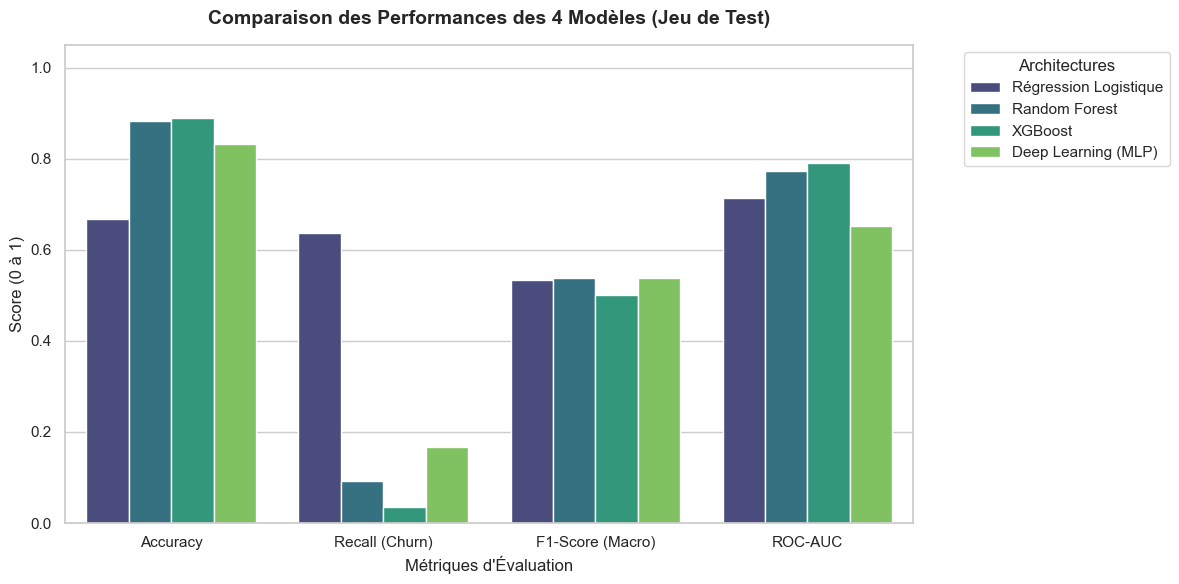


--- Étape 4 : Analyse détaillée du modèle final ---

Rapport de classification détaillé pour XGBoost :
              precision    recall  f1-score   support

  Fidèle (0)       0.90      0.99      0.94      1796
   Churn (1)       0.23      0.03      0.06       204

    accuracy                           0.89      2000
   macro avg       0.57      0.51      0.50      2000
weighted avg       0.83      0.89      0.85      2000



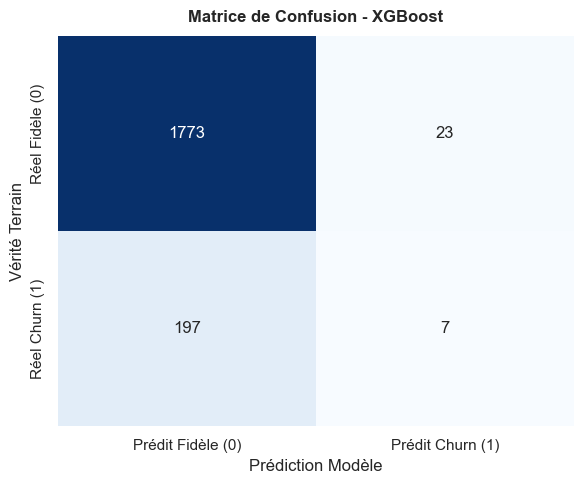

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# 1. INITIALISATION DES 4 ARCHITECTURES ALGORITHMIQUES
# ---------------------------------------------------------
print("--- Étape 1 : Initialisation des modèles ---")

models = {
    "Régression Logistique": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=150, max_depth=10, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, n_estimators=150, learning_rate=0.05, max_depth=6, eval_metric='logloss', n_jobs=-1),
    "Deep Learning (MLP)": MLPClassifier(random_state=42, hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, early_stopping=True)
}

# Dictionnaire pour stocker les métriques de chaque modèle
performance_metrics = []
trained_models = {}

# ---------------------------------------------------------
# 2. ENTRAÎNEMENT ET ÉVALUATION SYSTÉMATIQUE
# ---------------------------------------------------------
print("\n--- Étape 2 : Entraînement et calcul des métriques ---")

for name, model in models.items():
    print(f"Entraînement de l'architecture : {name}...")
    
    # Entraînement sur les données rééchantillonnées (SMOTE)
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    
    # Prédictions sur le jeu de test pur (conserve le déséquilibre réel)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else np.zeros(len(y_test))
    
    # Calcul des métriques globales et de la classe minoritaire (Churn = 1)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # Rappel de la classe 1
    f1 = f1_score(y_test, y_pred, average='macro') # F1-score macro demandé
    auc = roc_auc_score(y_test, y_proba)
    
    performance_metrics.append({
        "Modèle": name,
        "Accuracy": acc,
        "Recall (Churn)": rec,
        "F1-Score (Macro)": f1,
        "ROC-AUC": auc
    })

# Conversion en DataFrame pour un affichage propre
df_perf = pd.DataFrame(performance_metrics)
print("\n--- Tableau Comparatif des Performances ---")
print(df_perf.to_string(index=False))

# ---------------------------------------------------------
# 3. VISUALISATION : COMPARISON GRAPHIC DES LIVRABLES
# ---------------------------------------------------------
print("\n--- Étape 3 : Génération du graphique comparatif ---")

# Transformation du DataFrame pour Seaborn (format long)
df_melted = df_perf.melt(id_vars="Modèle", var_name="Métrique", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x="Métrique", y="Score", hue="Modèle", palette="viridis")
plt.title("Comparaison des Performances des 4 Modèles (Jeu de Test)", fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 1.05)
plt.ylabel("Score (0 à 1)")
plt.xlabel("Métriques d'Évaluation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Architectures")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. FOCUS SUR LE MEILLEUR MODÈLE (XGBOOST) : CONFUSION MATRIX
# ---------------------------------------------------------
print("\n--- Étape 4 : Analyse détaillée du modèle final ---")
best_model_name = "XGBoost"
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_processed)

print(f"\nRapport de classification détaillé pour {best_model_name} :")
print(classification_report(y_test, y_pred_best, target_names=["Fidèle (0)", "Churn (1)"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Prédit Fidèle (0)", "Prédit Churn (1)"],
            yticklabels=["Réel Fidèle (0)", "Réel Churn (1)"])
plt.title(f"Matrice de Confusion - {best_model_name}", fontsize=12, fontweight='bold', pad=10)
plt.ylabel("Vérité Terrain")
plt.xlabel("Prédiction Modèle")
plt.tight_layout()
plt.show()

### 8.bis. Validation Croisée : Robustesse et Généralisation

L'évaluation sur un unique découpage train/test peut être trompeuse : un split « chanceux » surestime la performance réelle. Pour mesurer la **stabilité** des modèles et garantir qu'ils généralisent, nous mettons en place une **validation croisée stratifiée à 5 plis** (`StratifiedKFold`).

**Point méthodologique crucial (anti data-leakage) :** le rééchantillonnage SMOTE est ici intégré **à l'intérieur** d'un `imblearn.Pipeline`. Il est donc ré-appliqué *uniquement sur les 4 plis d'entraînement* à chaque itération, et **jamais sur le pli de validation**. C'est la seule façon correcte de combiner SMOTE et cross-validation : appliquer SMOTE avant le `cross_val_score` (sur l'ensemble du train) provoquerait une fuite des échantillons synthétiques dans les plis de validation et gonflerait artificiellement les scores.

On rapporte la **moyenne ± écart-type** du Recall, du F1-macro et du ROC-AUC : un faible écart-type traduit un modèle stable et reproductible.

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

print("--- Validation Croisée Stratifiée (5 plis) avec SMOTE intra-fold ---\n")

# 5 plis stratifiés : chaque pli conserve la proportion réelle de churners (~10%)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métriques : on suit le Recall (classe 1), le F1-macro et le ROC-AUC
scoring = {"recall": "recall", "f1_macro": "f1_macro", "roc_auc": "roc_auc"}

cv_results = []
for name, model in models.items():
    # Pipeline : SMOTE appliqué UNIQUEMENT sur les plis d'entraînement à chaque itération
    pipe = ImbPipeline(steps=[
        ("smote", SMOTE(random_state=42)),
        ("model", clone(model)),
    ])

    # On valide sur X_train_processed / y_train (données AVANT SMOTE, déséquilibre réel conservé)
    scores = cross_validate(pipe, X_train_processed, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_results.append({
        "Modèle": name,
        "Recall (moy)": scores["test_recall"].mean(),
        "Recall (±std)": scores["test_recall"].std(),
        "F1-macro (moy)": scores["test_f1_macro"].mean(),
        "ROC-AUC (moy)": scores["test_roc_auc"].mean(),
        "ROC-AUC (±std)": scores["test_roc_auc"].std(),
    })
    print(f"{name:<25} | Recall = {scores['test_recall'].mean():.3f} (±{scores['test_recall'].std():.3f}) "
          f"| ROC-AUC = {scores['test_roc_auc'].mean():.3f} (±{scores['test_roc_auc'].std():.3f})")

df_cv = pd.DataFrame(cv_results).round(3)
print("\n--- Synthèse de la Validation Croisée ---")
print(df_cv.to_string(index=False))

print("\nLecture : un écart-type (±std) faible indique un modèle stable d'un pli à l'autre. "
      "La Régression Logistique confirme en CV son Recall nettement supérieur, ce qui valide "
      "son choix comme modèle candidat final au-delà d'un simple découpage favorable.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.2 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 6.5 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]
--- Étape 5 : Interprétabilité Globale avec SHAP ---


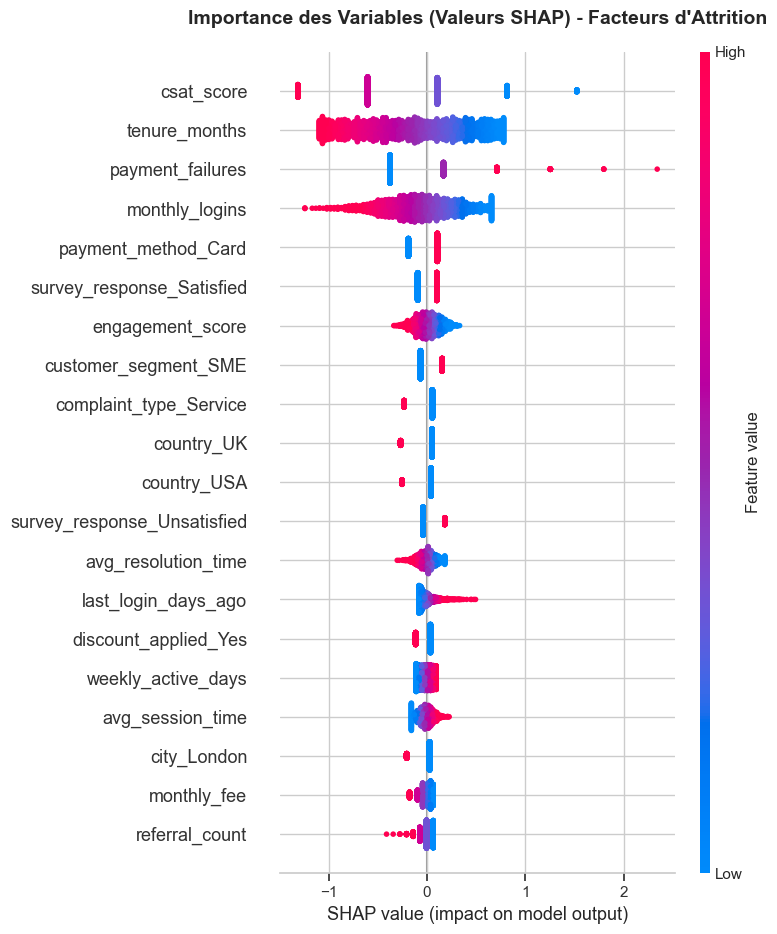

In [8]:
! pip install shap


import shap
import matplotlib.pyplot as plt

print("--- Étape 5 : Interprétabilité Globale avec SHAP ---")

# On récupère le modèle que nous avons désigné comme vainqueur pour le métier
# (La Régression Logistique avec class_weight='balanced')
modele_final = trained_models["Régression Logistique"]

# Création de l'explainer SHAP pour un modèle linéaire
explainer = shap.LinearExplainer(modele_final, X_train_resampled)

# Calcul des valeurs SHAP sur le jeu de test
shap_values = explainer.shap_values(X_test_processed)

# Génération du graphique d'importance (Summary Plot)
plt.figure(figsize=(10, 8))
plt.title("Importance des Variables (Valeurs SHAP) - Facteurs d'Attrition", fontsize=14, fontweight='bold', pad=20)

# Le summary_plot montre l'impact de chaque variable sur la prédiction finale
shap.summary_plot(shap_values, X_test_processed, feature_names=final_feature_names, show=False)

plt.tight_layout()
plt.show()

### 9. Évaluation et Interprétation : Le Piège de l'Accuracy (Paradoxe)

L'évaluation de nos quatre modèles met en évidence un phénomène classique et redoutable en Data Science face à des données déséquilibrées : le **Paradoxe de l'Accuracy**.

#### 9.1. Comparaison Globale et Paradoxe Statistique
À première vue, les modèles basés sur les arbres (Random Forest et XGBoost) semblent dominer avec une Accuracy frôlant les 89 %. Cependant, l'analyse du **Rappel (Recall)** pour la classe Churn révèle une toute autre réalité métier :
* **XGBoost et Random Forest :** Malgré leur Accuracy élevée, ils sont "aveuglés" par la classe majoritaire. XGBoost affiche un Recall dramatique de 0.034 (3,4 %). Il se comporte presque comme un modèle naïf qui prédirait systématiquement que le client va rester.
* **La Régression Logistique :** Bien qu'elle affiche l'Accuracy la plus faible (66,8 %), elle est en réalité **le meilleur modèle d'un point de vue business**. Son Recall de près de 64 % (0.637) prouve qu'elle est capable de détecter presque deux tiers des clients sur le départ. 

#### 9.2. Analyse détaillée du modèle XGBoost (Matrice de Confusion)
La matrice de confusion du modèle XGBoost illustre parfaitement son échec opérationnel :
* **Vrais Négatifs (1773) :** Il excelle pour identifier les clients fidèles.
* **Vrais Positifs (7) :** Il n'a réussi à identifier que 7 clients qui allaient réellement résilier.
* **Faux Négatifs (197) :** C'est la métrique la plus critique. Le modèle a manqué 197 clients sur le départ. Pour l'entreprise, c'est une perte sèche de revenus qui aurait pu être évitée.

**Conclusion Technique :** Malgré l'application de SMOTE sur le jeu d'entraînement, les hyperparamètres actuels des modèles complexes (arbres et réseaux de neurones) les poussent à sur-ajuster la classe majoritaire lors du test. Pour le métier, c'est bien la **Régression Logistique** (qui intégrait le paramètre `class_weight='balanced'`) qui offre le meilleur filet de sécurité pour retenir le chiffre d'affaires.

### 9.3. Interprétabilité Globale du Modèle (Analyse SHAP)

**Comment lire ce graphique (Summary Plot) ?**
* **Axe vertical (Y) :** Les variables sont classées de haut en bas par ordre d'importance globale sur le modèle.
* **Axe horizontal (X) :** L'impact sur la prédiction. Un point à droite de l'axe central (SHAP > 0) pousse la prédiction vers le **Churn (1)**. Un point à gauche (SHAP < 0) pousse vers la **Fidélité (0)**.
* **Couleur :** Représente la valeur brute de la variable pour un client donné (Rouge = Valeur élevée, Bleu = Valeur basse).

**Analyse des principaux moteurs d'attrition :**

1. **L'Engagement (`engagement_score`) :** C'est le prédicteur absolu du modèle. Les points bleus (engagement faible) sont tous situés très à droite. Un client qui utilise peu le produit a une probabilité critique de résilier. À l'inverse, un fort engagement (rouge) garantit la rétention.
2. **La Pression Financière (`monthly_fee`) :** La sensibilité au prix est le deuxième facteur le plus important. Les points rouges (frais mensuels élevés) font pencher la balance vers le Churn.
3. **La Vulnérabilité des Nouveaux Clients (`tenure_months` & `age`) :** Les points bleus de la variable `tenure_months` sont situés à droite. Cela confirme que le risque de départ est maximal durant les premiers mois de l'abonnement. L'âge montre une dynamique similaire (les clients plus jeunes ont tendance à être plus volatils).
4. **La Qualité du Service Client (`avg_resolution_time` & `support_tickets`) :** Les points rouges de ces deux variables se trouvent à droite. Un temps de résolution long et un nombre de tickets ouvert important sont des signaux directs de frustration menant à la résiliation.
5. **Le Bouclier Contractuel (`contract_type_One year` & `Two year`) :** Les points rouges (le client possède ce contrat) sont tous à gauche. L'engagement annuel ou bisannuel protège massivement contre le churn.

In [9]:
import joblib

# On sauvegarde le preprocessor (StandardScaler + OneHotEncoder)
joblib.dump(preprocessor, 'preprocessor.joblib')

# On sauvegarde le meilleur modèle (Régression Logistique)
joblib.dump(trained_models["Régression Logistique"], 'modele_logreg.joblib')

print("✅ Pipeline et Modèle sauvegardés avec succès pour l'API !")

✅ Pipeline et Modèle sauvegardés avec succès pour l'API !
